# Linear Regression Analysis (Python)

This notebook analyzes the relationship between years of experience and salary using a simple linear regression model. It reports the fitted equation, model fit, a prediction at 6 years of experience, and a polished regression graph.

## Step 1: Load the Data

We read the CSV file into a pandas DataFrame. Each row represents an observation with predictor and response variables.

In [1]:
import os
from pathlib import Path

cache_dir = Path.cwd() / ".matplotlib_cache"
cache_dir.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(cache_dir)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x_column = "YearsExperience"
y_column = "Salary"
predict_years = 6.0
output_file = "linear_regression_python_output.png"

data = pd.read_csv("regression_data.csv")
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Step 2: Fit a Simple Linear Regression Model

We fit the model `Salary = beta_0 + beta_1 * YearsExperience` using ordinary least squares.

In [2]:
x = data[[x_column]].values
y = data[y_column].values

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

intercept = float(model.intercept_)
slope = float(model.coef_[0])
equation = f"Salary = {intercept:.4f} + {slope:.4f} * YearsExperience"

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Regression equation: {equation}")

Slope: 8285.2921
Intercept: 29203.5227
Regression equation: Salary = 29203.5227 + 8285.2921 * YearsExperience


## Step 3: Evaluate the Model and Predict Salary

We calculate R-squared and predict the salary for 6 years of experience.

In [3]:
r2 = float(r2_score(y, y_pred))
predicted_salary = float(model.predict([[predict_years]])[0])

print(f"R-squared: {r2:.4f}")
print(
    f"Predicted salary at {predict_years:g} years of experience: "
    f"{predicted_salary:.2f}"
)

R-squared: 0.7852
Predicted salary at 6 years of experience: 78915.28


## Step 4: Create the Regression Graph

The final graph shows observed data, the fitted line, the regression equation, R-squared, and the highlighted prediction at 6 years of experience.

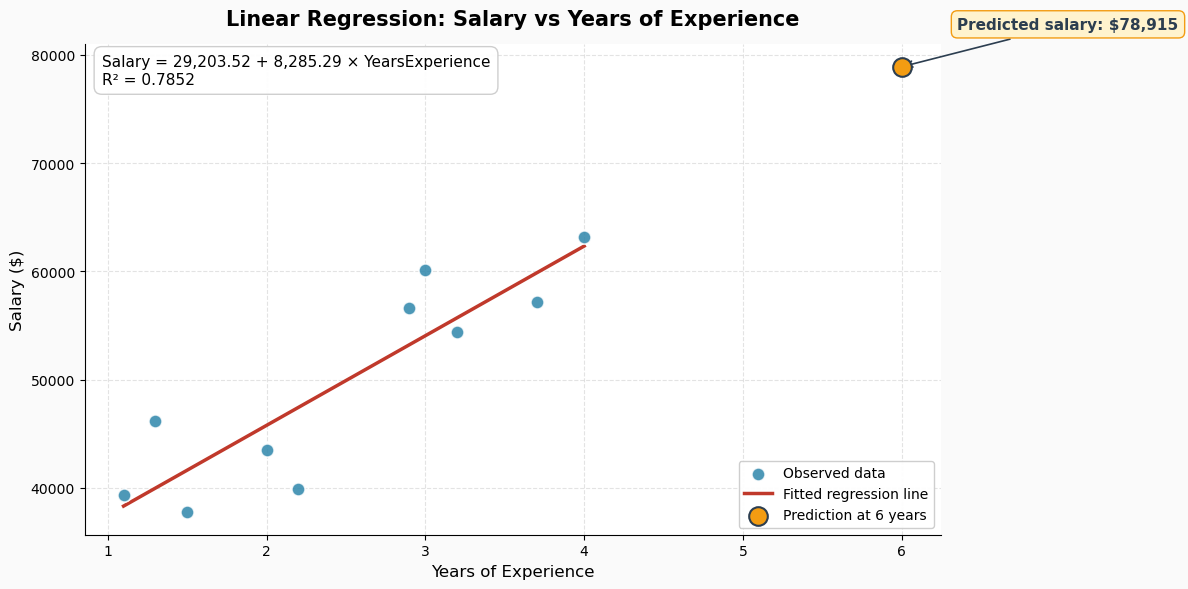

Saved regression plot to linear_regression_python_output.png


In [4]:
def format_currency(value: float) -> str:
    return f"${value:,.0f}"


x_values = data[x_column].values
y_values = data[y_column].values
x_line = np.linspace(x_values.min(), x_values.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#ffffff")

ax.scatter(
    x_values,
    y_values,
    s=90,
    alpha=0.85,
    color="#2E86AB",
    edgecolors="white",
    linewidths=1.2,
    label="Observed data",
    zorder=3,
)
ax.plot(
    x_line,
    y_line,
    color="#C0392B",
    linewidth=2.5,
    label="Fitted regression line",
    zorder=2,
)
ax.scatter(
    [predict_years],
    [predicted_salary],
    s=180,
    color="#F39C12",
    edgecolors="#2C3E50",
    linewidths=1.5,
    label=f"Prediction at {predict_years:g} years",
    zorder=4,
)

ax.annotate(
    f"Predicted salary: {format_currency(predicted_salary)}",
    xy=(predict_years, predicted_salary),
    xytext=(predict_years + 0.35, predicted_salary + 3500),
    fontsize=11,
    fontweight="bold",
    color="#2C3E50",
    arrowprops={"arrowstyle": "->", "color": "#2C3E50", "lw": 1.2},
    bbox={"boxstyle": "round,pad=0.4", "facecolor": "#FFF3CD", "edgecolor": "#F39C12"},
)

stats_text = (
    f"Salary = {intercept:,.2f} + {slope:,.2f} × YearsExperience\n"
    f"R² = {r2:.4f}"
)
ax.text(
    0.02,
    0.98,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.95},
)

ax.set_title(
    "Linear Regression: Salary vs Years of Experience",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Years of Experience", fontsize=12)
ax.set_ylabel("Salary ($)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower right", frameon=True, framealpha=0.95)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(output_file, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved regression plot to {output_file}")

## Summary

The fitted model estimates salary as a linear function of years of experience. The regression equation, R-squared, and the predicted salary at 6 years are reported above, and the saved graph matches the standalone Python script output.

In [5]:
print("Analysis complete.")
print(f"Regression equation: {equation}")
print(f"R-squared: {r2:.4f}")
print(f"Predicted salary at 6 years: {predicted_salary:.2f}")

Analysis complete.
Regression equation: Salary = 29203.5227 + 8285.2921 * YearsExperience
R-squared: 0.7852
Predicted salary at 6 years: 78915.28
